In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
ref = pd.read_csv('../dev/ncbi_salmonella_fruit_veg_pol.csv')
df = pd.read_csv('../ncbi_590_data.csv')
df = df[df['is_usa_based'] == 1]
df['primary_mode_fruit_veg_pol'] = df['isolation_source'].copy()
# Apply the mapping from the reference DataFrame
df['primary_mode_fruit_veg_pol'] = df['primary_mode_fruit_veg_pol'].replace(ref.set_index('before')['after'].to_dict())

C:\Users\bryan\AppData\Local\Temp\ipykernel_18040\1428374911.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../ncbi_590_data.csv')


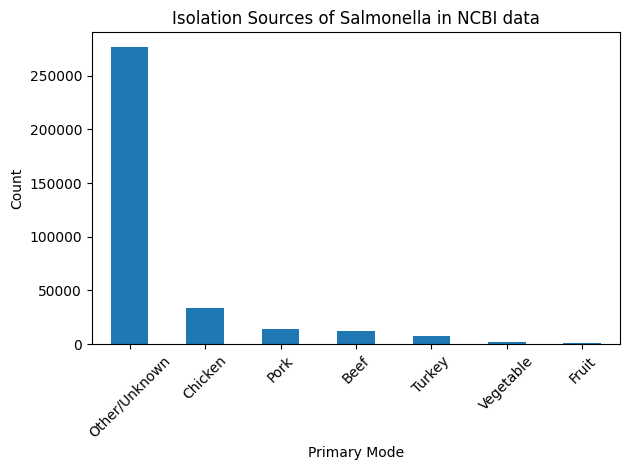

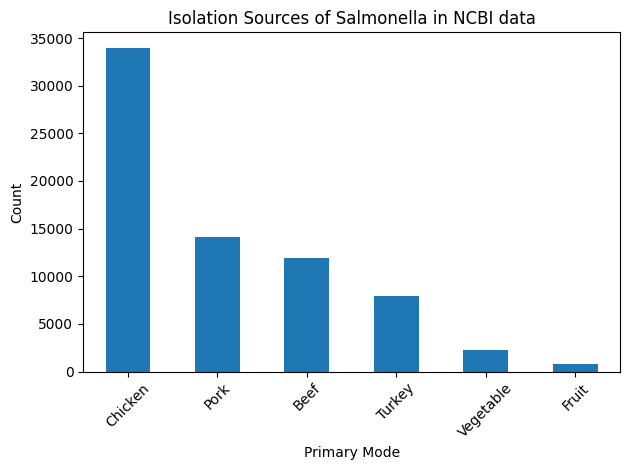

In [17]:
#Make a bar chart of the primary_mode_fruit_veg_pol column. Only include the top 7 values
top_values = df['primary_mode_fruit_veg_pol'].value_counts().nlargest(7)
top_values.plot(kind='bar')
plt.title('Isolation Sources of Salmonella in NCBI data')
plt.xlabel('Primary Mode')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_7_primary_modes_fruit_veg.png')
plt.show()

#Make another bar chart, but leave out Other/Unknown
top_values_no_other = df[df['primary_mode_fruit_veg_pol'] != 'Other/Unknown']['primary_mode_fruit_veg_pol'].value_counts().nlargest(6)
top_values_no_other.plot(kind='bar')
plt.title('Isolation Sources of Salmonella in NCBI data')
plt.xlabel('Primary Mode')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_7_primary_modes_fruit_veg_no_other.png')
# Show the plots
plt.show()


In [21]:
df['serotype'].value_counts().nlargest(50)
#serotype_counts = df['serotype'].value_counts().nlargest(4).index
df['serotype'].isnull().sum()


np.int64(361595)

In [22]:
df.head(3)

,genome,geo_loc_name,collection_date,strain,host,serotype,isolate,isolation_source,source_type,geo_loc_name_is_missing,is_usa_based,usa_state,new_isolation_source,collection_year,month,nors_primary_mode_map,primary_mode_fruit_veg_pol
0,GCA_000173695.1,USA,missing,CDC07-0191,NaN,NaN,NaN,missing,NaN,False,1.0,Unknown,Missing,missing,NaN,Indeterminate/unknown,Other/Unknown
1,GCA_000188355.2,USA: RI,missing,495297-1,NaN,NaN,FDA_2010_144_Black Pepper-6,peppercorn,Food,False,1.0,RHODE ISLAND,Uncategorized,missing,NaN,peppercorn,Vegetable
2,GCA_000188375.2,USA: RI,missing,495297-3,NaN,NaN,FDA_2010_145_Black Pepper-5,peppercorn,Food,False,1.0,RHODE ISLAND,Uncategorized,missing,NaN,peppercorn,Vegetable


In [25]:
df['host'].value_counts().nlargest(10)

host
missing                212479
Missing                 30217
Homo sapiens            16972
Sus scrofa               4716
Bovine                   3887
Gallus gallus            3194
Bos taurus               2836
bovine                   2427
Meleagris gallopavo       980
porcine                   670
Name: count, dtype: int64